In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# 1. Load Data
print("Step 1: Loading 'Model3_Category_Inventory.csv'...")
df = pd.read_csv('Model3_Category_Inventory.csv')

Step 1: Loading 'Model3_Category_Inventory.csv'...


In [4]:
# 2. Define Features and Targets
# We are now predicting 9 numbers at once!
target_categories = [
    'Bakery', 'Branded', 'Coffee', 'Coffee_beans', 
    'Drinking_Chocolate', 'Flavours', 'Loose_Tea', 
    'Packaged_Chocolate', 'Tea'
]
features = ['store_location', 'month', 'day_of_week', 'is_weekend', 'shift', 'total_shift_cups']

X = df[features]
y = df[target_categories]

In [6]:
# 3. Pipeline Setup
print("Step 2: Building Multi-Output Pipeline...")
categorical_features = ['store_location', 'shift', 'day_of_week']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

Step 2: Building Multi-Output Pipeline...


In [8]:
# 4. Split and Train
print("Step 3: Training the Inventory Engine...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_pipeline.fit(X_train, y_train)

Step 3: Training the Inventory Engine...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [10]:
# 5. Evaluate and Print Metrics
print("\n" + "="*40)
print("INVENTORY MODEL METRICS (R-SQUARED)")
print("="*40)
y_pred = model_pipeline.predict(X_test)
r2_scores = r2_score(y_test, y_pred, multioutput='raw_values')

for cat, score in zip(target_categories, r2_scores):
    print(f"{cat:20} : {score:.4f}")


INVENTORY MODEL METRICS (R-SQUARED)
Bakery               : 0.8130
Branded              : 0.2098
Coffee               : 0.9578
Coffee_beans         : 0.3919
Drinking_Chocolate   : 0.7069
Flavours             : 0.7610
Loose_Tea            : 0.3138
Packaged_Chocolate   : 0.2777
Tea                  : 0.9263


          Category      MAE     RMSE  R-Squared
            Bakery 3.904942 5.519007   0.812955
           Branded 0.510572 0.861005   0.209828
            Coffee 6.054283 7.943567   0.957788
      Coffee_beans 0.983647 1.756308   0.391909
Drinking_Chocolate 3.387450 4.637806   0.706894
          Flavours 3.244654 4.613852   0.760992
         Loose_Tea 0.678756 1.063133   0.313757
Packaged_Chocolate 0.358181 0.562527   0.277733
               Tea 6.156078 8.378651   0.926279


['model3_inventory_forecast.pkl']

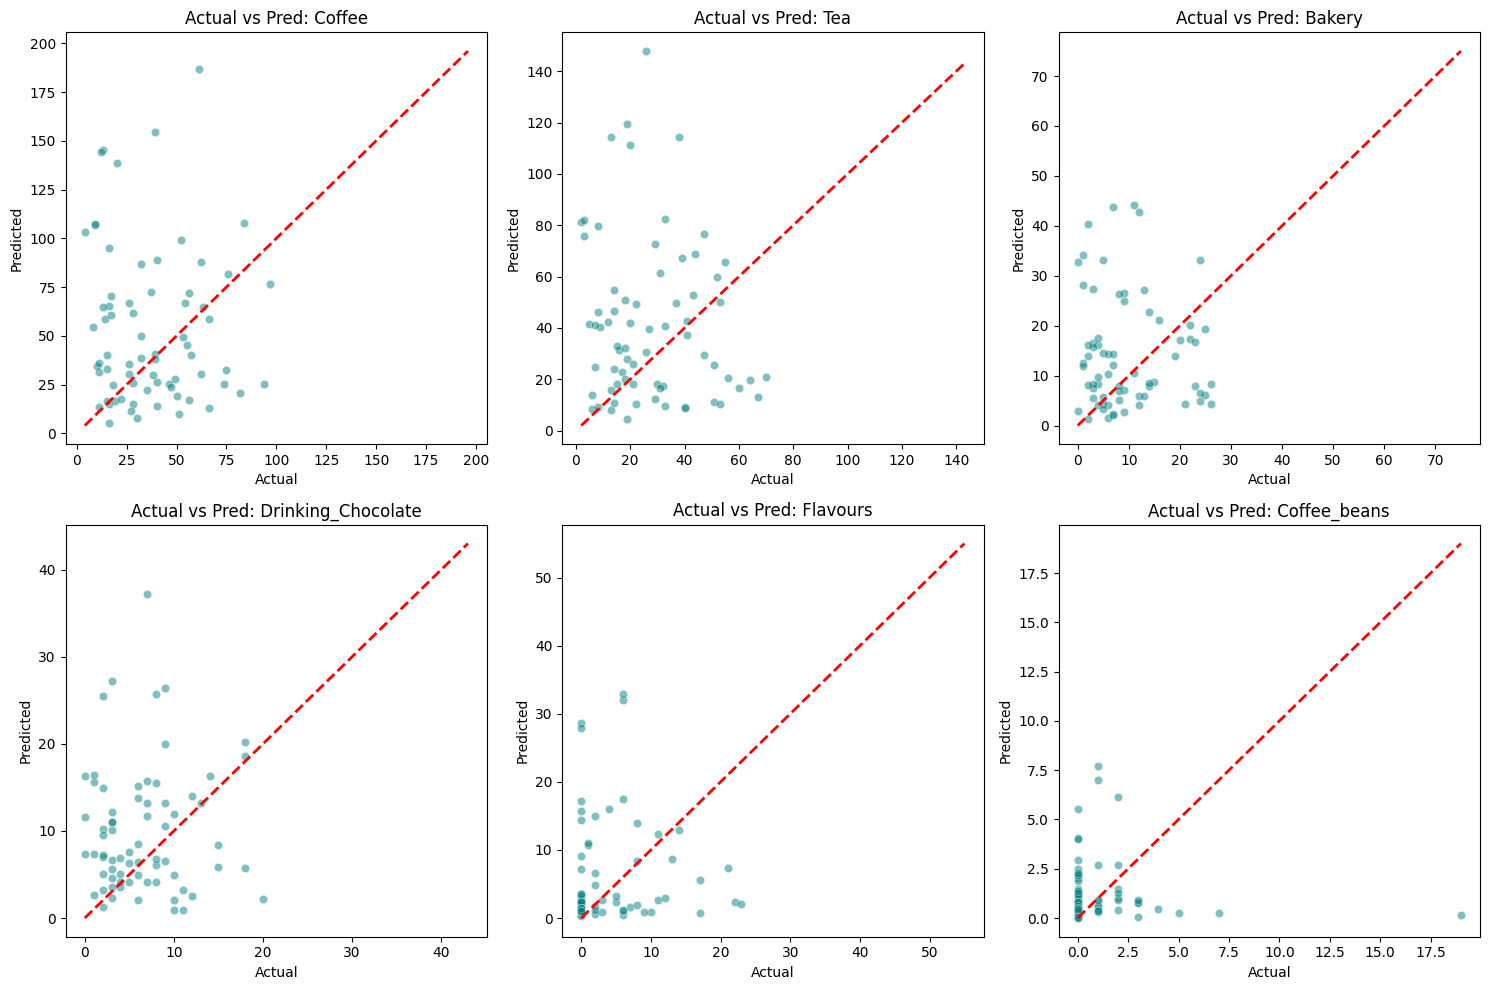

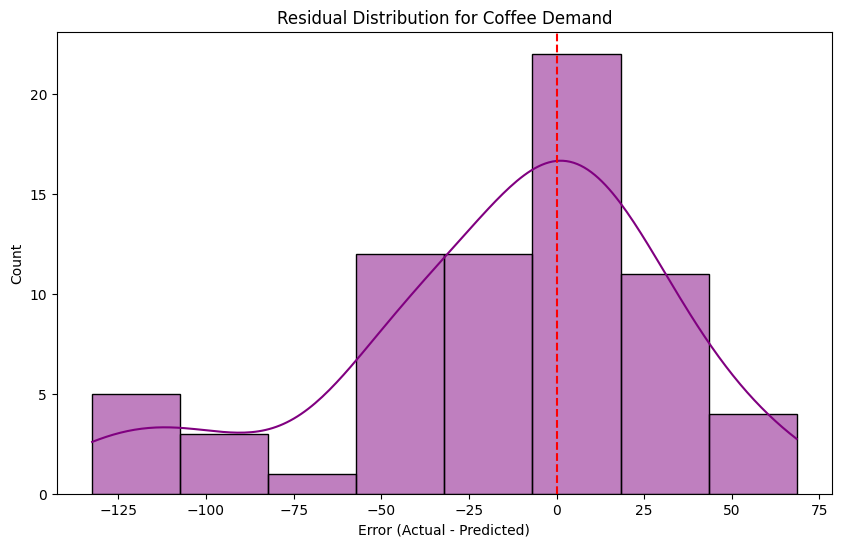

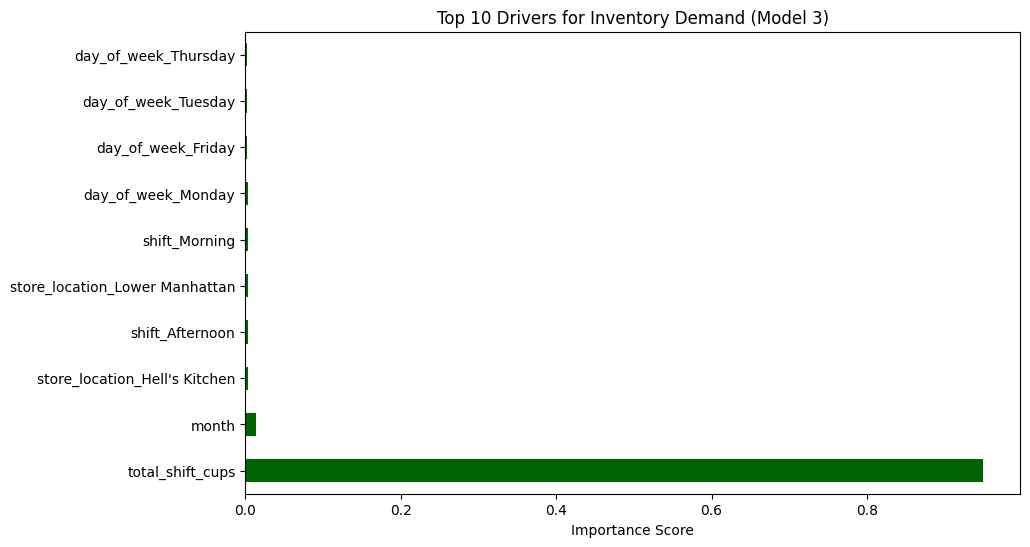

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# 1. Load Data
df = pd.read_csv('Model3_Category_Inventory.csv')

# 2. Define Features and Targets
target_categories = [
    'Bakery', 'Branded', 'Coffee', 'Coffee_beans', 
    'Drinking_Chocolate', 'Flavours', 'Loose_Tea', 
    'Packaged_Chocolate', 'Tea'
]
features = ['store_location', 'month', 'day_of_week', 'is_weekend', 'shift', 'total_shift_cups']

X = df[features]
y = df[target_categories]

# 3. Pipeline
categorical_features = ['store_location', 'shift', 'day_of_week']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 4. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_pipeline.fit(X_train, y_train)

# 5. Predict
y_pred = model_pipeline.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=target_categories)

# 6. Metrics Calculation
metrics_list = []
for cat in target_categories:
    mae = mean_absolute_error(y_test[cat], y_pred_df[cat])
    mse = mean_squared_error(y_test[cat], y_pred_df[cat])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test[cat], y_pred_df[cat])
    metrics_list.append({
        'Category': cat,
        'MAE': mae,
        'RMSE': rmse,
        'R-Squared': r2
    })

metrics_df = pd.DataFrame(metrics_list)
print(metrics_df.to_string(index=False))

# 7. Visual 1: Actual vs Predicted Grid (Top 6 categories)
top_cats = ['Coffee', 'Tea', 'Bakery', 'Drinking_Chocolate', 'Flavours', 'Coffee_beans']
plt.figure(figsize=(15, 10))
for i, cat in enumerate(top_cats):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=y_test[cat], y=y_pred_df[cat], alpha=0.5, color='teal')
    plt.plot([y_test[cat].min(), y_test[cat].max()], [y_test[cat].min(), y_test[cat].max()], 'r--', lw=2)
    plt.title(f'Actual vs Pred: {cat}')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
plt.tight_layout()
plt.savefig('m3_actual_vs_predicted_grid.png')

# 8. Visual 2: Residuals Distribution (Focus on Coffee)
plt.figure(figsize=(10, 6))
residuals_coffee = y_test['Coffee'] - y_pred_df['Coffee']
sns.histplot(residuals_coffee, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution for Coffee Demand')
plt.xlabel('Error (Actual - Predicted)')
plt.savefig('m3_residuals_coffee.png')

# 9. Visual 3: Feature Importance
ohe_feature_names = model_pipeline.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_features)
all_feature_names = list(ohe_feature_names) + ['month', 'is_weekend', 'total_shift_cups']
importances = model_pipeline.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='darkgreen')
plt.title('Top 10 Drivers for Inventory Demand (Model 3)')
plt.xlabel('Importance Score')
plt.savefig('m3_feature_importance.png')

# Final Export
joblib.dump(model_pipeline, 'model3_inventory_forecast.pkl')